### Router

Router는 요청을 분류해 적절한 처리 경로로 전달한다. 코드 규칙, 임베딩 유사도, LLM을 판단의 성격에 맞게 조합한다.

```text
요청 → 빠르고 확실한 판단 → 전문 노드
              ↓ 애매함
           LLM 판단 → 전문 노드 또는 fallback
```

In [1]:
from typing import Literal, TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-3.6-flash")
llm_lite = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

### 라우팅 방식 선택

| 방식 | 적합한 판단 | 특징 |
|---|---|---|
| Deterministic | 형식·키워드처럼 확정 가능한 조건 | 빠르고 예측 가능함 |
| LLM | 맥락 해석이 필요한 의도 | 유연하지만 비용과 지연이 있음 |
| Semantic | 대표 문장과 의미가 가까운 요청 | 빠르지만 예시와 threshold에 민감함 |
| Hybrid | 확실한 요청과 애매한 요청이 섞인 환경 | 비용과 정확도의 균형을 잡기 쉬움 |

### Deterministic Routing

Deterministic Routing은 state의 값을 명시적 규칙으로 검사해 경로를 결정한다. 실제 서비스에서는 요청 유형, 주문 상태, 사용자 권한, 입력 형식처럼 확실하게 판별할 수 있는 조건을 사용한다.

아래 예제는 키워드 규칙으로 단순화했다. 하나의 경로만 일치하면 해당 경로를 반환하고, 충돌하거나 일치하지 않으면 `uncertain`을 반환한다.

In [2]:
Route = Literal["refund", "shipping", "general", "uncertain"]
ROUTE_KEYWORDS = {
    "refund": ("환불", "반품", "결제 취소"),
    "shipping": ("배송", "택배", "도착", "운송장"),
    "general": ("회원", "등급", "재질", "영업시간"),
}

def deterministic_route(query: str) -> Route:
    matched = [route for route, words in ROUTE_KEYWORDS.items()
               if any(word in query for word in words)]
    return matched[0] if len(matched) == 1 else "uncertain"

for query in ["상품을 환불하고 싶어요", "택배가 언제 도착하나요?",
              "반품 수거와 배송 일정을 알려주세요", "회원 등급이 궁금해요"]:
    print(query, "→", deterministic_route(query))

상품을 환불하고 싶어요 → refund
택배가 언제 도착하나요? → shipping
반품 수거와 배송 일정을 알려주세요 → uncertain
회원 등급이 궁금해요 → general


### LLM Routing

Structured Output으로 목적지를 제한한다. 어느 경로에도 확실히 속하지 않는 요청을 위해 `uncertain`을 포함한다.

In [3]:
class Classification(BaseModel):
    category: Route = Field(description="refund, shipping, general 또는 uncertain")
    reason: str = Field(description="분류 근거 한 문장")

router_prompt = PromptTemplate.from_template(
    """고객 문의를 분류하세요.
refund: 환불·반품·결제 취소
shipping: 배송 조회·도착 일정·운송장
general: 그 밖의 일반 상담
uncertain: 여러 경로가 필요하거나 의도가 불명확함
문의: {query}"""
)
classifier = llm_lite.with_structured_output(Classification)
router_chain = router_prompt | classifier

def llm_route(query: str) -> Classification:
    return router_chain.invoke({"query": query})

print(llm_route("물건을 돌려보냈는데 다음 절차가 궁금해요").model_dump())

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'category': 'refund', 'reason': '고객이 물건을 돌려보냈다는 점에서 환불·반품 관련 문의로 분류됩니다.'}


`reason`은 관찰과 디버깅에 사용하고 분기는 제한된 `category`로 수행한다. LLM이 생성한 임의의 확률값은 보정된 확률이 아니므로 confidence처럼 그대로 사용하지 않는다.

### Hybrid Routing과 Fallback

명확한 요청은 규칙으로 처리하고 애매한 요청만 LLM으로 보낸다. LLM이 `uncertain`을 반환하거나 호출에 실패하면 clarification 경로로 보낸다.

In [4]:
class CustomerState(TypedDict, total=False):
    query: str
    category: Route
    route_source: str
    reason: str
    response: str

def classify_hybrid(state: CustomerState):
    category = deterministic_route(state["query"])
    if category != "uncertain":
        return {"category": category, "route_source": "rule", "reason": "단일 규칙 일치"}
    try:
        result = llm_route(state["query"])
        return {"category": result.category, "route_source": "llm", "reason": result.reason}
    except Exception:
        return {"category": "uncertain", "route_source": "fallback", "reason": "분류 호출 실패"}

def answer(state, role):
    result = llm.invoke(f"{role}로서 안내하세요.\n문의: {state['query']}")
    return {"response": result.text}

def handle_refund(state): return answer(state, "환불 전문 상담원")
def handle_shipping(state): return answer(state, "배송 전문 상담원")
def handle_general(state): return answer(state, "고객 상담원")
def ask_clarification(state):
    return {"response": "환불, 배송, 일반 문의 중 어느 내용인지 구체적으로 알려주세요."}
def route_by_category(state): return state["category"]

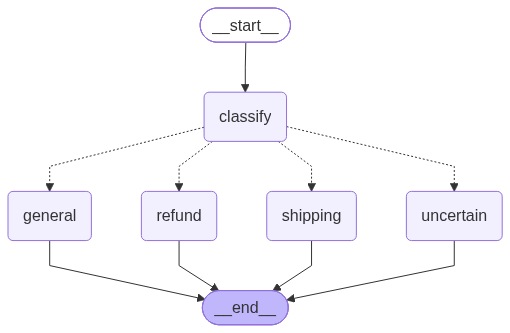

In [5]:
builder = StateGraph(CustomerState)
builder.add_node("classify", classify_hybrid)
builder.add_node("refund", handle_refund)
builder.add_node("shipping", handle_shipping)
builder.add_node("general", handle_general)
builder.add_node("uncertain", ask_clarification)

builder.add_edge(START, "classify")
builder.add_conditional_edges("classify", route_by_category, {name: name for name in ("refund", "shipping", "general", "uncertain")})
for node in ("refund", "shipping", "general", "uncertain"):
    builder.add_edge(node, END)
    
hybrid_graph = builder.compile()
display(Image(hybrid_graph.get_graph().draw_mermaid_png()))

In [6]:
for query in ["상품을 환불하고 싶어요", "물건을 돌려보냈는데 다음 절차가 궁금해요",
              "반품 수거와 새 상품 배송을 함께 처리해 주세요"]:
    result = hybrid_graph.invoke({"query": query})
    print(query, "→", result["category"], result["route_source"])
    print(result["response"][:50], "\n")

상품을 환불하고 싶어요 → refund rule
안녕하세요, 고객님. **환불 전문 상담원**입니다. 
저희 제품을 이용해 주셨는데, 환불 

물건을 돌려보냈는데 다음 절차가 궁금해요 → refund llm
안녕하세요, 고객님! 소중한 문의 감사드립니다. 환불 전문 상담원입니다. 

물건을 이미  

반품 수거와 새 상품 배송을 함께 처리해 주세요 → shipping llm
안녕하세요, 고객님! 언제나 신속하고 정확한 배송을 도와드리는 **배송 전문 상담원**입니 



### Semantic Routing

route별 대표 문장을 Chroma에 저장하고 가장 가까운 문서의 metadata에서 경로를 가져온다. relevance score가 threshold보다 낮으면 LLM으로 fallback한다. 대표 문장과 threshold는 검증 데이터로 조정해야 한다.

In [7]:
ROUTE_EXAMPLES = {
    "refund": ["상품을 환불하고 싶어요", "결제를 취소하고 싶어요", "반품 방법을 알려주세요"],
    "shipping": ["택배가 언제 오나요", "배송 상태를 조회해 주세요", "운송장이 궁금해요"],
    "general": ["회원 등급이 궁금해요", "상품 재질을 알려주세요", "영업시간이 궁금해요"],
}
route_documents = []
route_ids = []

for route, texts in ROUTE_EXAMPLES.items():
    for index, text in enumerate(texts):
        route_documents.append(
            Document(page_content=text, metadata={"route": route})
        )
        route_ids.append(f"{route}-{index}")

route_store = Chroma.from_documents(
    documents=route_documents,
    embedding=embeddings,
    ids=route_ids,
    collection_name="semantic-router",
)

In [8]:
SEMANTIC_THRESHOLD = 0.63

def semantic_route(query: str) -> tuple[Route, float]:
    results = route_store.similarity_search_with_relevance_scores(query, k=1)
    document, score = results[0]
    if score < SEMANTIC_THRESHOLD:
        return "uncertain", score
    return document.metadata["route"], score

for query in ["결제한 돈을 돌려받고 싶어요", "내 물건이 어디 있나요?", "선물을 추천해 주세요"]:
    route, score = semantic_route(query)
    print(f"{query} → {route} ({score:.3f})")

결제한 돈을 돌려받고 싶어요 → refund (0.731)
내 물건이 어디 있나요? → shipping (0.646)
선물을 추천해 주세요 → uncertain (0.563)


In [9]:
def classify_semantic_llm(state: CustomerState):
    category, score = semantic_route(state["query"])
    if category != "uncertain":
        return {"category": category, "route_source": "semantic", "reason": f"similarity={score:.3f}"}
    try:
        result = llm_route(state["query"])
        return {"category": result.category, "route_source": "llm_fallback",
                "reason": f"similarity={score:.3f}; {result.reason}"}
    except Exception:
        return {"category": "uncertain", "route_source": "fallback", "reason": "LLM 호출 실패"}

앞의 그래프에서 `classify_hybrid` 대신 `classify_semantic_llm`을 등록하면 Semantic Router와 LLM fallback을 결합할 수 있다.

### Flat Routing과 Hierarchical Routing

```text
Flat: User → Router → Refund 
                    → Shipping
                    → Account
                    → Product

Hierarchical: 
                    User
                     ↓
                Domain Router
              /       |       \
         Finance    Support   Engineering
            ↓          ↓          ↓
         Router      Router      Router
        /     \      /    \      /    \
      SQL    RAG   Refund FAQ  GitHub Logs
```

목적지가 적은 현재 예제에는 Flat Router가 적합하다. Hierarchical Router는 선택지가 많고 domain 경계가 명확할 때 관리와 정확도에 도움이 되지만, 여러 Router를 순차적으로 거치므로 latency가 늘 수 있다.

| 비교 | Flat | Hierarchical |
|---|---|---|
| Router 호출 | 보통 한 번 | 두 번 이상 가능 |
| 적합한 상황 | 목적지가 적음 | 목적지가 많고 계층이 명확함 |

### Hierarchical Routing 예제

계층 구조 자체에 집중하기 위해 각 Router의 판단을 간단한 규칙으로 구현한다. 첫 Router는 세부 목적지를 직접 고르지 않고 domain만 선택하며, 주문과 계정 요청은 각각의 하위 Router가 다시 분류한다.

In [10]:
from typing import Literal, TypedDict

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph


class HierarchicalState(TypedDict, total=False):
    query: str
    domain: Literal["order", "account", "product"]
    destination: str
    response: str


def classify_domain(state: HierarchicalState):
    query = state["query"]
    if any(word in query for word in ("환불", "배송", "주문")):
        return {"domain": "order"}
    if any(word in query for word in ("등급", "프로필", "계정")):
        return {"domain": "account"}
    return {"domain": "product"}


def classify_order(state: HierarchicalState):
    destination = "refund" if "환불" in state["query"] else "shipping"
    return {"destination": destination}


def classify_account(state: HierarchicalState):
    destination = "grade" if "등급" in state["query"] else "profile"
    return {"destination": destination}


def route_domain(state): return state["domain"]
def route_destination(state): return state["destination"]
def complete(state): return {"response": f"{state['destination']} 경로에서 처리합니다."}
def handle_product(state): return {"destination": "product", "response": "상품 경로에서 처리합니다."}

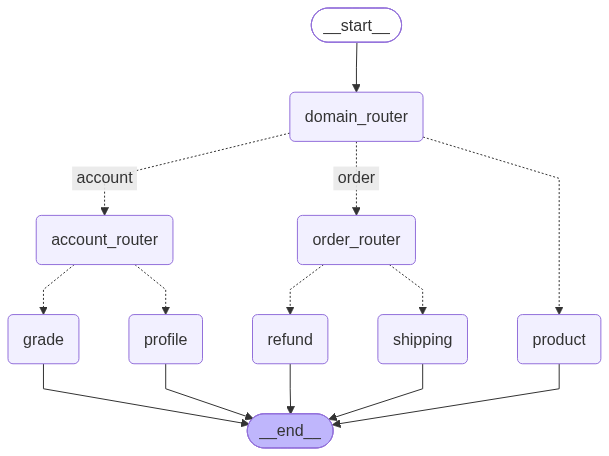

In [11]:
hierarchy_builder = StateGraph(HierarchicalState)
hierarchy_builder.add_node("domain_router", classify_domain)
hierarchy_builder.add_node("order_router", classify_order)
hierarchy_builder.add_node("account_router", classify_account)
hierarchy_builder.add_node("product", handle_product)

for destination in ("refund", "shipping", "grade", "profile"):
    hierarchy_builder.add_node(destination, complete)

hierarchy_builder.add_edge(START, "domain_router")
hierarchy_builder.add_conditional_edges(
    "domain_router", route_domain,
    {"order": "order_router", "account": "account_router", "product": "product"},
)
hierarchy_builder.add_conditional_edges(
    "order_router", route_destination,
    {"refund": "refund", "shipping": "shipping"},
)
hierarchy_builder.add_conditional_edges(
    "account_router", route_destination,
    {"grade": "grade", "profile": "profile"},
)
for node in ("refund", "shipping", "grade", "profile", "product"):
    hierarchy_builder.add_edge(node, END)

hierarchical_graph = hierarchy_builder.compile()
display(Image(hierarchical_graph.get_graph().draw_mermaid_png()))

In [12]:
for query in ("주문을 환불하고 싶어요", "회원 등급이 궁금해요", "상품 재질을 알려주세요"):
    result = hierarchical_graph.invoke({"query": query})
    print(f"{query} → {result['domain']} → {result['destination']}")

주문을 환불하고 싶어요 → order → refund
회원 등급이 궁금해요 → account → grade
상품 재질을 알려주세요 → product → product


### Router 평가 기준

- routing accuracy: 올바른 목적지를 선택한 비율
- fallback rate: 자동 분류하지 않고 보류한 비율
- unsafe routing rate: 위험한 잘못된 경로를 선택한 비율
- latency: 최종 처리까지 걸린 시간
- token cost: Router와 처리 노드가 사용한 전체 토큰
